# Spiking Handwritten Digits Classifier using `superneuroabm`

This tutorial demonstrates how to classify handwritten digits (sklearn 8×8 digits, 10 classes) using **SuperNeuroABM**, a GPU-accelerated agent-based spiking neural network simulator.

We build a two-layer feedforward SNN with semi-supervised STDP learning:
- **64 input LIF neurons** (one per pixel)
- **640 STDP synapses** (fully connected, bounded to [0, 1])
- **10 output LIF neurons** (one per class)
- **10 target synapses** (force correct output neuron to fire during training)

During training, input spikes use amplitude encoding (pixel value × scale),
target spikes force the correct output neuron to fire (at T+1), and
bounded STDP learns which input pixels correlate with each class.
The LTD/LTP amplitude ratio ensures common pixels (active across many classes)
receive balanced potentiation/depression and stay near zero, while class-specific
pixels accumulate net LTP only for their correct output neuron.
During inference, only the learned weights drive the outputs.

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn.datasets
import sklearn.model_selection
import sklearn.metrics
from math import ceil
from pathlib import Path
from tqdm import tqdm

from superneuroabm.model import NeuromorphicModel

## Load and Explore the Digits Dataset

In [2]:
digits = sklearn.datasets.load_digits(n_class=10)
print(f"Data shape: {digits.data.shape}")
print(f"Target shape: {digits.target.shape}")
print(f"Classes: {np.unique(digits.target)}")
print(f"Pixel range: [{digits.data.min()}, {digits.data.max()}]")

Data shape: (1797, 64)
Target shape: (1797,)
Classes: [0 1 2 3 4 5 6 7 8 9]
Pixel range: [0.0, 16.0]


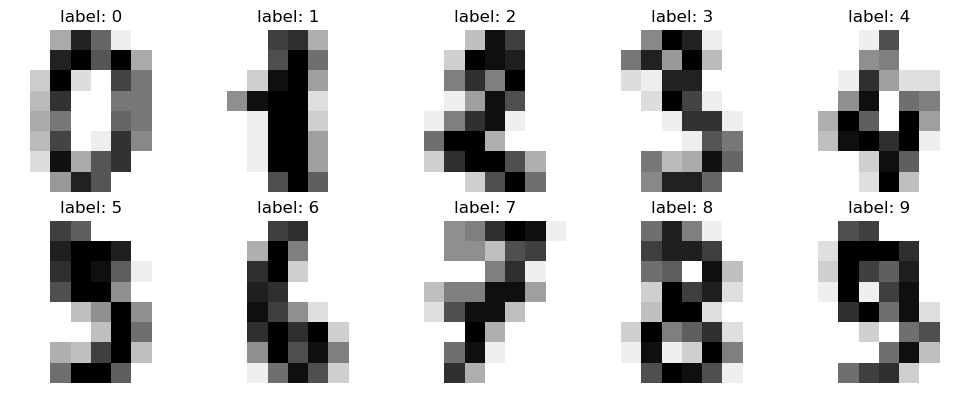

In [3]:
# Show example digits
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, image, label in zip(axes.flatten(), digits.images[:10], digits.target[:10]):
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
    ax.set_title(f"label: {label}")
    ax.set_axis_off()
plt.tight_layout()
plt.show()

In [4]:
# 50/50 train/test split (shuffle for interleaved class presentations — critical for STDP LTD)
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    digits.data, digits.target, test_size=0.5, shuffle=True, random_state=42
)
n_classes = len(np.unique(digits.target))
input_size = X_train.shape[1]  # 64 pixels
print(f"Train: {len(X_train)}, Test: {len(X_test)}, Classes: {n_classes}, Input size: {input_size}")

Train: 898, Test: 899, Classes: 10, Input size: 64


## Network Architecture

We use a custom config (`digits_config.yaml`) with the built-in **bounded STDP** rule (`stdp_type=2`).
Learning rule configs are in a separate `learning_rule:` section, following the current API convention.

| Component | Count | Config | Purpose |
|-----------|-------|--------|---------|
| Input somas | 64 | `digits_input_config` | LIF neurons, one per pixel |
| Output somas | 10 | `digits_output_config` | LIF neurons, one per class |
| Input synapses | 64 | `digits_input_synapse_config` | External → input somas, weight=20, no learning |
| Target synapses | 10 | `digits_target_synapse_config` | External → output somas, weight=20, no learning |
| Learning synapses | 640 | `digits_learning_synapse_config` + `digits_bounded` | Input → output, bounded STDP [0, 1] |

**Key design choices:**
- Amplitude encoding: each pixel's spike amplitude is proportional to its intensity (`pixel_value × 2.0/16`).
- **Target spikes** during training force the correct output neuron to fire (at T+1), providing the
  supervised signal that STDP needs to develop class-specific weight patterns.
- **Bounded STDP** (`stdp_type=2`) uses exponential pair-wise updates with hard weight clamping to [0, 1].
  LTP (`a_exp_pre=0.1`) is stronger per-event than LTD (`a_exp_post=0.04`), so class-specific
  pixels accumulate net LTP for their correct output neuron, while common pixels (active in many
  classes) receive balanced LTP/LTD across all outputs.
- Initial weight of 0.3 keeps output neurons quiet until STDP builds up class-specific connections.
- Shuffled training data ensures interleaved class presentations, which is critical for trace-based STDP:
  consecutive different-class samples keep post_trace non-zero, enabling effective LTD.

In [5]:
# Create model with custom config (memristive STDP is built-in at stdp_type=3)
CONFIG_DIR = Path(".").resolve()
model = NeuromorphicModel(
    user_config=CONFIG_DIR / "digits_config.yaml",
    enable_internal_state_tracking=False,
)

In [6]:
def create_layer(model, size, config_name):
    """Create a layer of LIF somas."""
    ids = []
    for _ in range(size):
        soma_id = model.create_soma(
            breed="lif_soma",
            config_name=config_name,
        )
        ids.append(soma_id)
    return ids


def create_input_synapses(model, soma_ids, config_name):
    """Create one external-input synapse (pre=-1) per soma."""
    ids = []
    for soma_id in soma_ids:
        syn_id = model.create_synapse(
            breed="single_exp_synapse",
            pre_soma_id=-1,
            post_soma_id=soma_id,
            config_name=config_name,
        )
        ids.append(syn_id)
    return ids


def fully_connect(model, pre_ids, post_ids, config_name):
    """Create STDP-enabled synapses between all pairs."""
    syn_ids = []
    for pre_id in pre_ids:
        for post_id in post_ids:
            syn_id = model.create_synapse(
                breed="single_exp_synapse",
                pre_soma_id=pre_id,
                post_soma_id=post_id,
                config_name=config_name,
                learning_rule="exp_pair_wise_stdp_bounded",
                learning_rule_config="digits_bounded",
            )
            syn_ids.append(syn_id)
    return syn_ids

In [7]:
# Build the network
input_somas = create_layer(model, input_size, config_name="digits_input_config")
output_somas = create_layer(model, n_classes, config_name="digits_output_config")

input_synapses = create_input_synapses(model, input_somas, config_name="digits_input_synapse_config")
target_synapses = create_input_synapses(model, output_somas, config_name="digits_target_synapse_config")
learning_synapses = fully_connect(
    model, input_somas, output_somas,
    config_name="digits_learning_synapse_config",
)

print(f"Input somas: {len(input_somas)}")
print(f"Output somas: {len(output_somas)}")
print(f"Input synapses: {len(input_synapses)}")
print(f"Target synapses: {len(target_synapses)}")
print(f"Learning synapses: {len(learning_synapses)}")
print(f"Total agents: {len(input_somas) + len(output_somas) + len(input_synapses) + len(target_synapses) + len(learning_synapses)}")

Input somas: 64
Output somas: 10
Input synapses: 64
Target synapses: 10
Learning synapses: 640
Total agents: 788


## Training Encoding

Each training sample is presented over **10 ticks** (spacing must exceed refractory period of 5 ticks + fire latency of 2 ticks = 7 ticks, so input somas clear refractory before the next sample arrives):
- **Tick T+0**: Amplitude-encoded input spikes (`pixel_value × SPIKE_SCALE`), matching tutorial 01's approach
- **Tick T+1**: Target spike forces the correct output neuron to fire (matching tutorial 01's T+1 offset)
- **Ticks T+2..T+9**: STDP processes, voltages decay, refractory clears

We run **2 training epochs**. Between epochs, `reset(retain_parameters=True)` preserves learned
weights while clearing internal state, and spikes are re-injected for the next pass.

In [8]:
# Encoding parameters
SPIKE_SCALE = 2.0 / 16.0  # amplitude scale matching tutorial 01
TICKS_PER_SAMPLE = 10      # spacing between samples; must exceed refractory(5) + fire_latency(2) = 7
TARGET_OFFSET = 1          # target spike at T+1, matching tutorial 01
N_EPOCHS = 2               # number of training epochs

def encode_training_spikes(model, X_train, y_train, input_synapses, target_synapses):
    """Encode training data as amplitude-scaled spike lists and inject into the model."""
    input_spike_lists = {syn_id: [] for syn_id in input_synapses}
    target_spike_lists = {syn_id: [] for syn_id in target_synapses}

    for sample_idx, (image, label) in enumerate(zip(X_train, y_train)):
        t_base = sample_idx * TICKS_PER_SAMPLE
        for pixel_idx, pixel_val in enumerate(image):
            amplitude = pixel_val * SPIKE_SCALE
            if amplitude > 0:
                input_spike_lists[input_synapses[pixel_idx]].append([t_base, amplitude])
        # Target spike forces correct output neuron to fire at T+1
        target_spike_lists[target_synapses[label]].append([t_base + TARGET_OFFSET, 1.0])

    for syn_id, spikes in input_spike_lists.items():
        if spikes:
            model.add_spike_list(syn_id, spikes)
    for syn_id, spikes in target_spike_lists.items():
        if spikes:
            model.add_spike_list(syn_id, spikes)

total_training_ticks = len(X_train) * TICKS_PER_SAMPLE
print(f"Training samples: {len(X_train)}")
print(f"Total training ticks per epoch: {total_training_ticks}")
print(f"Training epochs: {N_EPOCHS}")

Training samples: 898
Total training ticks per epoch: 8980
Training epochs: 2


In [9]:
# Setup and run multi-epoch training (no normalization needed — bounded STDP constrains weights)
model.setup(use_gpu=True)
model.set_recorded_somas([])

encode_training_spikes(model, X_train, y_train, input_synapses, target_synapses)
for epoch in range(N_EPOCHS):
    if epoch > 0:
        model.reset(retain_parameters=True)
        encode_training_spikes(model, X_train, y_train, input_synapses, target_synapses)
    model.simulate(ticks=total_training_ticks)
    print(f"Epoch {epoch + 1}/{N_EPOCHS} complete")

Epoch 1/2 complete


Epoch 2/2 complete


## Extract and Visualize Learned Weights

In [10]:
# Extract the 64x10 weight matrix from learning synapses
# learning_synapses is ordered: [input_0->output_0, input_0->output_1, ..., input_63->output_9]
weight_matrix = np.zeros((input_size, n_classes))
for i, syn_id in enumerate(learning_synapses):
    hp = model.get_agent_property_value(id=syn_id, property_name="hyperparameters")
    weight = hp[0]
    pre_idx = i // n_classes
    post_idx = i % n_classes
    weight_matrix[pre_idx, post_idx] = weight

print(f"Weight matrix shape: {weight_matrix.shape}")
print(f"Weight range: [{weight_matrix.min():.4f}, {weight_matrix.max():.4f}]")

Weight matrix shape: (64, 10)
Weight range: [0.0764, 0.6114]


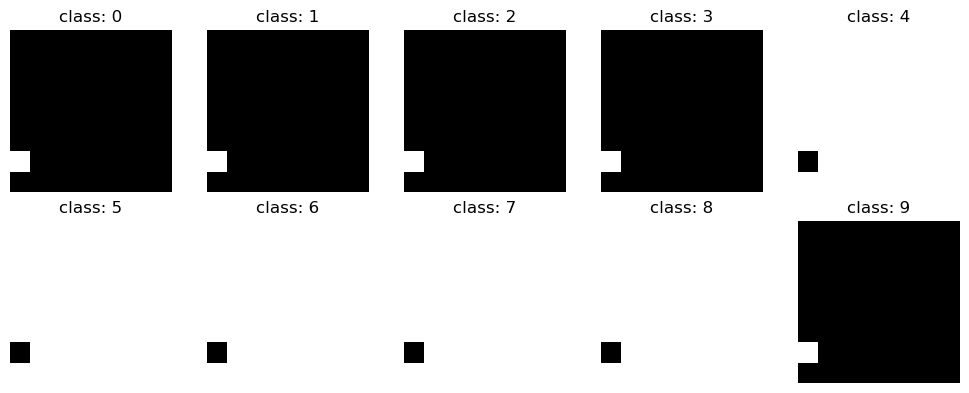

In [11]:
# Visualize learned weight patterns per class as 8x8 images
# Mean-subtracted: highlights what's *distinctive* about each class
images = weight_matrix.T.reshape(n_classes, 8, 8)
mean_image = images.mean(axis=0)
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, image, cls in zip(axes.flatten(), images, range(n_classes)):
    ax.imshow(image - mean_image, cmap=plt.cm.gray_r, interpolation="nearest")
    ax.set_title(f"class: {cls}")
    ax.set_axis_off()
plt.tight_layout()
plt.show()

## Per-Sample Inference with Spike Counting

After training, we disable STDP and run inference **one sample at a time** with
`reset(retain_parameters=True)` between samples. This fully clears internal state
(synaptic current, membrane voltage) so each sample is classified in isolation.

Following tutorial 01's approach, we use **spike counting** to decode the output:
the output neuron that fires the most spikes is the prediction. Ties are broken
by earliest spike time (faster response = more confident).

For inference, we lower input neuron thresholds for sensitivity and use the same
amplitude encoding scale as training, with repeated spikes over 20 ticks to allow
the network to integrate evidence.

In [12]:
# Prepare for inference: keep trained weights, disable learning
model.reset(retain_parameters=True)

# Disable STDP on all learning synapses
for syn_id in learning_synapses:
    lhp = model.get_agent_property_value(id=syn_id, property_name="learning_hyperparameters")
    lhp[0] = -1.0  # stdp_type = -1 (disabled)
    model.set_agent_property_value(syn_id, "learning_hyperparameters", lhp)

# Lower input vthr for inference sensitivity (tutorial 01 lowers input threshold too)
for soma_id in input_somas:
    hp = model.get_agent_property_value(id=soma_id, property_name="hyperparameters")
    hp[2] = -59.5  # vthr: 0.5mV above vrest, ensures all nonzero pixels spike
    model.set_agent_property_value(soma_id, "hyperparameters", hp)

# Keep output vthr at -45 (let them fire — we count spikes)

In [13]:
INFERENCE_TICKS = 25
INFER_INPUT_TICKS = 20
INFER_SPIKE_SCALE = SPIKE_SCALE  # same encoding scale as training

def infer_single(model, image, input_synapses, output_somas):
    """Run inference on a single image using spike counting (tutorial 01 approach)."""
    for pixel_idx, pixel_val in enumerate(image):
        amplitude = pixel_val * INFER_SPIKE_SCALE
        if amplitude > 0:
            spike_list = [[tick, amplitude] for tick in range(INFER_INPUT_TICKS)]
            model.add_spike_list(synapse_id=input_synapses[pixel_idx], spike_list=spike_list)

    model.simulate(ticks=INFERENCE_TICKS)

    # Count spikes per output neuron (tutorial 01 approach)
    spike_counts = []
    earliest_spikes = []
    for soma_id in output_somas:
        times = model.get_spike_times(soma_id)
        spike_counts.append(len(times))
        earliest_spikes.append(min(times) if len(times) > 0 else float('inf'))

    # Winner = most spikes, tie-break by earliest spike
    max_count = max(spike_counts)
    if max_count == 0:
        prediction = 0  # fallback: no spikes
    else:
        candidates = [i for i, c in enumerate(spike_counts) if c == max_count]
        prediction = min(candidates, key=lambda i: earliest_spikes[i])

    model.reset(retain_parameters=True)
    return prediction

## Evaluation

In [14]:
predictions = []
for image, real_answer in tqdm(zip(X_test, y_test), total=len(y_test)):
    pred = infer_single(model, image, input_synapses, output_somas)
    predictions.append((real_answer, pred))

accuracy = sum(1 for r, p in predictions if r == p) / len(predictions)
print(f"\nAccuracy: {accuracy:.2%}")

  0%|          | 0/899 [00:00<?, ?it/s]

  0%|          | 3/899 [00:00<00:41, 21.54it/s]

  1%|          | 6/899 [00:00<00:41, 21.51it/s]

  1%|          | 9/899 [00:00<00:41, 21.22it/s]

  1%|▏         | 12/899 [00:00<00:41, 21.16it/s]

...

 99%|█████████▉| 894/899 [00:55<00:00, 14.74it/s]

100%|█████████▉| 896/899 [00:55<00:00, 15.09it/s]

100%|█████████▉| 898/899 [00:55<00:00, 15.19it/s]

100%|██████████| 899/899 [00:55<00:00, 16.21it/s]


Accuracy: 9.12%


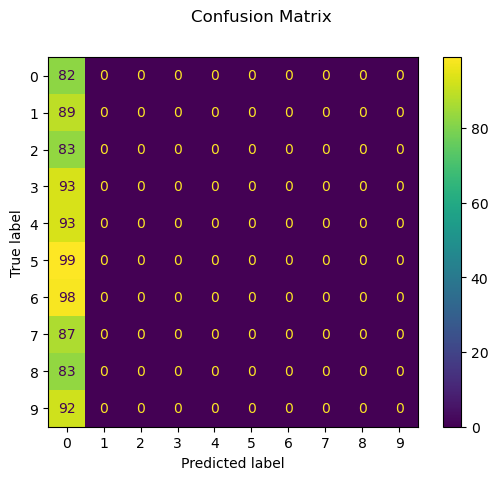

In [15]:
# Confusion matrix
real_labels, pred_labels = zip(*predictions)
disp = sklearn.metrics.ConfusionMatrixDisplay.from_predictions(real_labels, pred_labels)
disp.figure_.suptitle("Confusion Matrix")
plt.show()

In [16]:
# Per-class classification report
real_labels, pred_labels = zip(*predictions)
print(sklearn.metrics.classification_report(real_labels, pred_labels, zero_division=0))

              precision    recall  f1-score   support

           0       0.09      1.00      0.17        82
           1       0.00      0.00      0.00        89
           2       0.00      0.00      0.00        83
           3       0.00      0.00      0.00        93
           4       0.00      0.00      0.00        93
           5       0.00      0.00      0.00        99
           6       0.00      0.00      0.00        98
           7       0.00      0.00      0.00        87
           8       0.00      0.00      0.00        83
           9       0.00      0.00      0.00        92

    accuracy                           0.09       899
   macro avg       0.01      0.10      0.02       899
weighted avg       0.01      0.09      0.02       899

